# Split Sanity Check Inpaint

This notebook keeps model loading separate from inference settings. After a pipeline is loaded, change the prompt, seed, strength, guidance, steps, or LoRA scale in the settings cells and rerun only the inference cell below it.

## 1. Setup

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import DPMSolverMultistepScheduler, StableDiffusionInpaintPipeline
from PIL import Image, ImageOps


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "backend").exists() and (candidate / "frontend").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Run this notebook from the repo or notebooks directory.")


REPO_ROOT = find_repo_root()
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
IMAGE_PATH = REPO_ROOT / "test_images" / "satelite-image.png"
MASK_PATH = REPO_ROOT / "test_images" / "satelite-mask.png"
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "split_sanity_inpaint"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESOLUTION = 512
LOCAL_FILES_ONLY = True
INVERT_MASK = False
SAVE_RESULTS = True

print("repo root:", REPO_ROOT)
print("image:", IMAGE_PATH)
print("mask:", MASK_PATH)
print("output:", OUTPUT_DIR)


W0531 14:26:13.189000 46836 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


repo root: C:\Users\neman\Documents\UVPython\inpainting
image: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-image.png
mask: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-mask.png
output: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\split_sanity_inpaint


In [2]:
def load_image_and_mask(image_path: Path, mask_path: Path, resolution: int, invert_mask: bool = False):
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")
    if mask.size != image.size:
        mask = mask.resize(image.size, Image.Resampling.NEAREST)

    mask = mask.point(lambda value: 255 if value > 127 else 0)
    if invert_mask:
        mask = ImageOps.invert(mask)

    image = image.resize((resolution, resolution), Image.Resampling.BILINEAR)
    mask = mask.resize((resolution, resolution), Image.Resampling.NEAREST)
    mask = mask.point(lambda value: 255 if value > 127 else 0)
    return image, mask


def mask_overlay(image: Image.Image, mask: Image.Image) -> Image.Image:
    image_array = np.asarray(image.convert("RGB"), dtype=np.float32)
    mask_array = np.asarray(mask.convert("L")) > 127
    overlay = image_array.copy()
    overlay[mask_array] = overlay[mask_array] * 0.35 + np.array([255, 40, 40], dtype=np.float32) * 0.65
    return Image.fromarray(np.clip(overlay, 0, 255).astype(np.uint8))


def show_images(items, figsize=(18, 5)):
    fig, axes = plt.subplots(1, len(items), figsize=figsize)
    if len(items) == 1:
        axes = [axes]
    for axis, (title, item, cmap) in zip(axes, items):
        axis.imshow(item, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    plt.tight_layout()


def make_generator(seed: int | None, device: str):
    run_seed = int(seed) if seed is not None else int(time.time()) % 2_147_483_647
    return torch.Generator(device=device).manual_seed(run_seed), run_seed


def save_image(image: Image.Image, prefix: str, seed: int):
    if not SAVE_RESULTS:
        return None
    path = OUTPUT_DIR / f"{prefix}_{time.strftime('%Y%m%d_%H%M%S')}_seed_{seed}.png"
    image.save(path)
    latest_path = OUTPUT_DIR / f"latest_{prefix}.png"
    image.save(latest_path)
    return path


def load_inpaint_pipe():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=dtype,
        safety_checker=None,
        local_files_only=LOCAL_FILES_ONLY,
        use_safetensors=False,
    ).to(device)
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    pipe.set_progress_bar_config(disable=False)
    if device == "cuda":
        pipe.enable_attention_slicing()
    return pipe, device


In [3]:
test_image, test_mask = load_image_and_mask(IMAGE_PATH, MASK_PATH, RESOLUTION, INVERT_MASK)
mask_array = np.asarray(test_mask)
print("image size:", test_image.size)
print("mask values:", sorted(np.unique(mask_array).tolist()))
print("white/inpaint coverage:", f"{float((mask_array > 127).mean()):.2%}")

show_images([
    ("input", test_image, None),
    ("mask", test_mask, "gray"),
    ("repaint area", mask_overlay(test_image, test_mask), None),
])


FileNotFoundError: Image not found: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-image.png

## 2. Base Model

Run the load cell once. Then change the settings cell and rerun only the base inference cell.

In [4]:
base_pipe, base_device = load_inpaint_pipe()
print("base device:", base_device)
print("pipeline:", base_pipe.__class__.__name__)
print("unet input channels:", base_pipe.unet.config.in_channels)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

base device: cuda
pipeline: StableDiffusionInpaintPipeline
unet input channels: 9


In [7]:
# Edit this cell freely, then rerun the next cell only.
BASE_PROMPT = "small house surrounded by grass"
BASE_NEGATIVE_PROMPT = "blurry, distorted, low quality, cartoon, warped perspective, repeated artifacts"
BASE_SEED = 7
BASE_NUM_INFERENCE_STEPS = 40
BASE_GUIDANCE_SCALE = 5.5
BASE_STRENGTH = 0.9


  0%|          | 0/36 [00:00<?, ?it/s]

base seed: 7
saved: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\split_sanity_inpaint\base_20260526_054320_seed_7.png


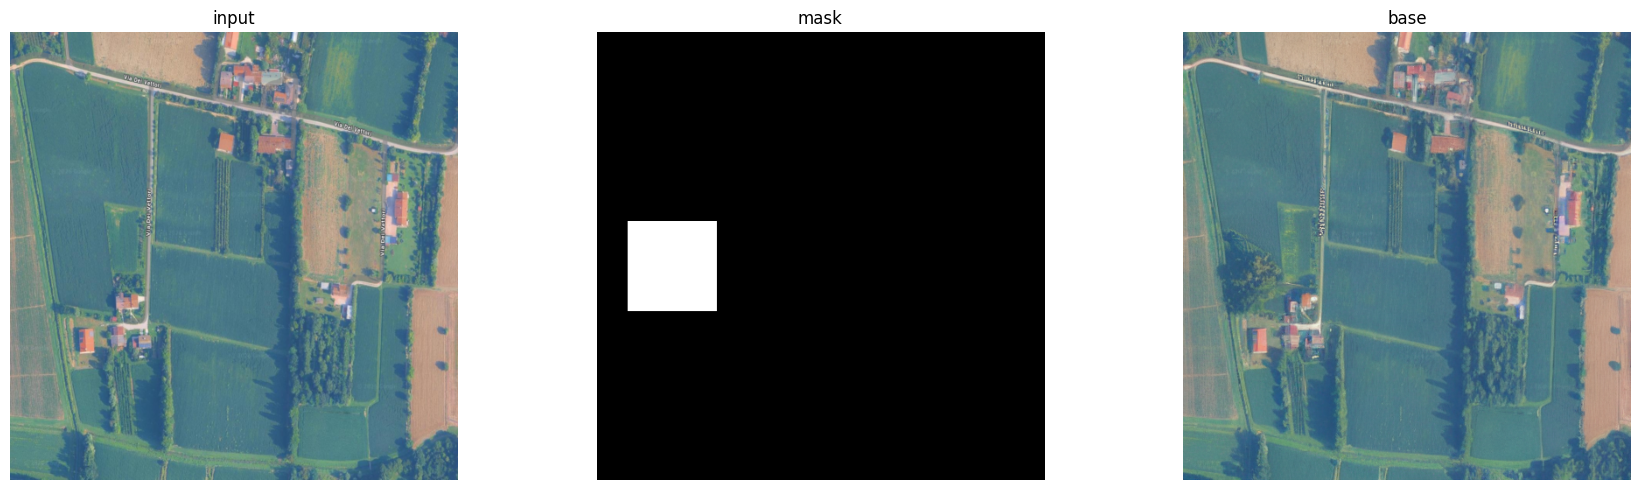

In [8]:
base_generator, BASE_RUN_SEED = make_generator(BASE_SEED, base_device)
base_result = base_pipe(
    prompt=BASE_PROMPT,
    negative_prompt=BASE_NEGATIVE_PROMPT,
    image=test_image,
    mask_image=test_mask,
    height=RESOLUTION,
    width=RESOLUTION,
    num_inference_steps=BASE_NUM_INFERENCE_STEPS,
    guidance_scale=BASE_GUIDANCE_SCALE,
    strength=BASE_STRENGTH,
    generator=base_generator,
).images[0]

saved_path = save_image(base_result, "base", BASE_RUN_SEED)
show_images([
    ("input", test_image, None),
    ("mask", test_mask, "gray"),
    ("base", base_result, None),
])
print("base seed:", BASE_RUN_SEED)
if saved_path is not None:
    print("saved:", saved_path)


## 3. LoRA Combined Model

Run the LoRA load cell once for a selected adapter. Then change the settings cell, including `LORA_SCALE`, and rerun only the LoRA inference cell.

In [9]:
# Change this only when you want to load a different adapter.
LORA_TO_TEST = "lora_small_house_set_sd15_inpaint"
LORA_ADAPTER_NAME = "selected_lora"
LORA_SEARCH_ROOTS = [
    REPO_ROOT / "notebooks" / "outputs",
    REPO_ROOT / "outputs",
    REPO_ROOT / "backend" / "models",
]


def lora_candidates(selection: str | Path):
    selected = Path(selection)
    if selected.is_absolute():
        yield selected
        return

    for root in LORA_SEARCH_ROOTS:
        yield root / selected
        yield root / selected / "pytorch_lora_weights.safetensors"
        yield root / selected.name


def resolve_lora(selection: str | Path | None) -> Path | None:
    if selection is None:
        return None
    checked = []
    for candidate in lora_candidates(selection):
        candidate = candidate.resolve()
        checked.append(candidate)
        if candidate.is_dir() and (candidate / "pytorch_lora_weights.safetensors").exists():
            return candidate
        if candidate.is_file():
            return candidate
    formatted = "\n".join(f"  - {path}" for path in checked)
    raise FileNotFoundError(f"Could not find LoRA selection {selection!r}. Checked:\n{formatted}")


SELECTED_LORA_PATH = resolve_lora(LORA_TO_TEST)
print("selected LoRA:", SELECTED_LORA_PATH if SELECTED_LORA_PATH is not None else "none")


selected LoRA: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_small_house_set_sd15_inpaint


In [10]:
if SELECTED_LORA_PATH is None:
    lora_pipe = None
    lora_device = None
    print("No LoRA selected.")
else:
    lora_pipe, lora_device = load_inpaint_pipe()
    if SELECTED_LORA_PATH.is_dir():
        lora_pipe.load_lora_weights(str(SELECTED_LORA_PATH), adapter_name=LORA_ADAPTER_NAME)
    else:
        lora_pipe.load_lora_weights(str(SELECTED_LORA_PATH.parent), weight_name=SELECTED_LORA_PATH.name, adapter_name=LORA_ADAPTER_NAME)
    print("lora device:", lora_device)
    print("loaded adapter:", LORA_ADAPTER_NAME)
    print("source:", SELECTED_LORA_PATH)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

lora device: cuda
loaded adapter: selected_lora
source: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_small_house_set_sd15_inpaint


In [13]:
# Edit this cell freely, then rerun the next cell only.
LORA_PROMPT = "small house"
LORA_NEGATIVE_PROMPT = "trees, vegetation, forest, bushes, blurry, distorted, low quality, cartoon, warped perspective, repeated artifacts"
LORA_SCALE = 0.9
LORA_SEED = BASE_RUN_SEED if "BASE_RUN_SEED" in globals() else 7
LORA_NUM_INFERENCE_STEPS = 40
LORA_GUIDANCE_SCALE = 5.5
LORA_STRENGTH = 0.9


  0%|          | 0/36 [00:00<?, ?it/s]

lora seed: 7
lora scale: 0.9
base vs lora mean abs diff: 0.6719156901041666
saved: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\split_sanity_inpaint\lora_scale_0.9_20260526_054410_seed_7.png


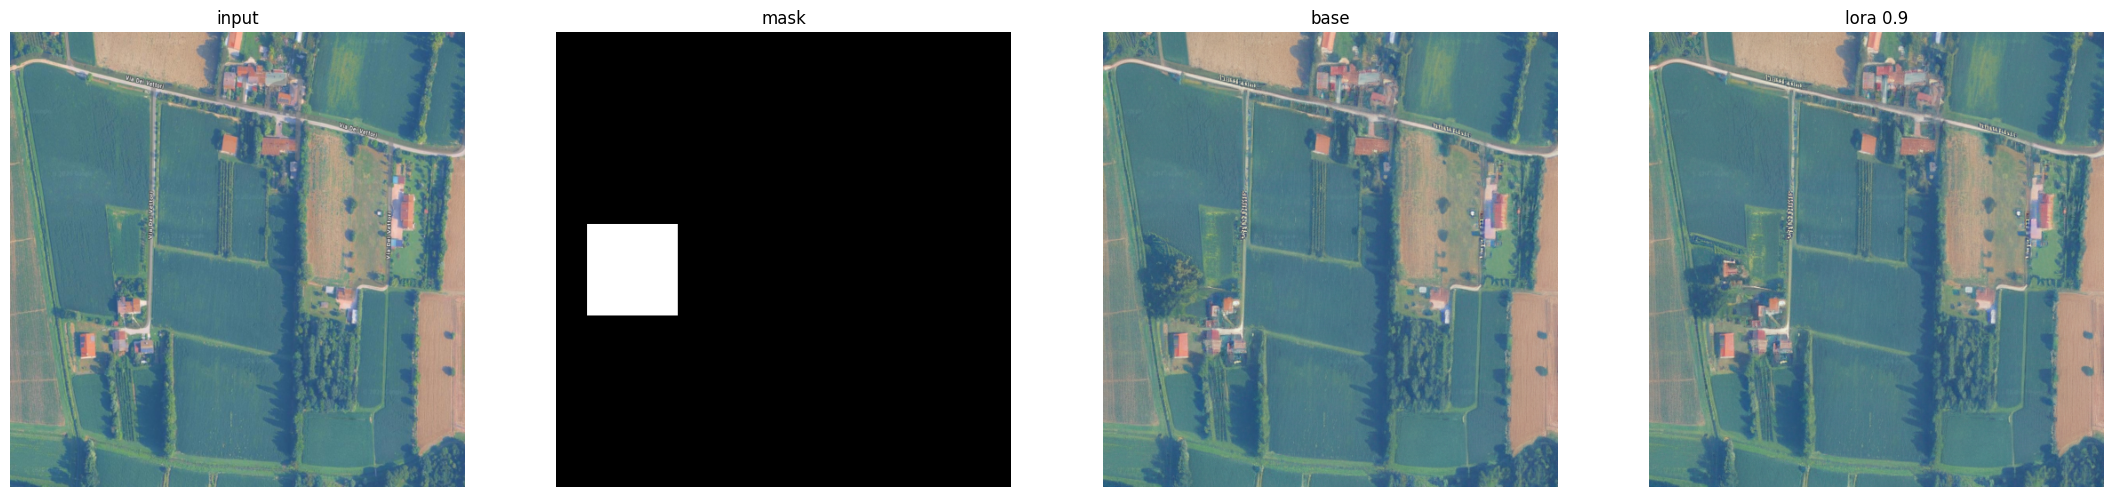

In [14]:
if lora_pipe is None:
    raise RuntimeError("Load a LoRA adapter first, or set LORA_TO_TEST to a valid adapter path.")

lora_pipe.enable_lora()
lora_pipe.set_adapters([LORA_ADAPTER_NAME], adapter_weights=[LORA_SCALE])
lora_generator, LORA_RUN_SEED = make_generator(LORA_SEED, lora_device)
lora_result = lora_pipe(
    prompt=LORA_PROMPT,
    negative_prompt=LORA_NEGATIVE_PROMPT,
    image=test_image,
    mask_image=test_mask,
    height=RESOLUTION,
    width=RESOLUTION,
    num_inference_steps=LORA_NUM_INFERENCE_STEPS,
    guidance_scale=LORA_GUIDANCE_SCALE,
    strength=LORA_STRENGTH,
    generator=lora_generator,
).images[0]

saved_path = save_image(lora_result, f"lora_scale_{LORA_SCALE}", LORA_RUN_SEED)
items = [
    ("input", test_image, None),
    ("mask", test_mask, "gray"),
]
if "base_result" in globals():
    items.append(("base", base_result, None))
items.append((f"lora {LORA_SCALE}", lora_result, None))
show_images(items, figsize=(22, 5))

print("lora seed:", LORA_RUN_SEED)
print("lora scale:", LORA_SCALE)
if "base_result" in globals():
    base_array = np.asarray(base_result.convert("RGB"), dtype=np.int16)
    lora_array = np.asarray(lora_result.convert("RGB"), dtype=np.int16)
    print("base vs lora mean abs diff:", float(np.abs(base_array - lora_array).mean()))
if saved_path is not None:
    print("saved:", saved_path)
